# Causal Inference for Policy Evaluation: DiD, Synthetic Control, and Instrumental Variables

**The problem.** Randomised A/B tests are the gold standard for causal questions, but most *policy* decisions — a new pricing rule, a promotional rollout, a regulation, a clinical intervention — cannot be randomised. The analyst is left with observational data and a set of structural methods that each make different assumptions about what the counterfactual would have been. The question this notebook answers: **given an observational panel dataset where a policy was rolled out to some units but not others, which causal estimator should we trust, and how do we check it against a known ground truth?**

**The approach.** On a simulated retail-chain scenario — a free-shipping promotion rolled out to roughly half the stores — we build a panel dataset with:

- known true average treatment effect on the treated (ATT),
- realistic selection bias (urban, close-to-DC, high-manager-skill stores were rolled out to first),
- parallel pre-trends by construction, and
- a valid instrument (distance to distribution centre) that satisfies exclusion by design.

Then we walk through the full causal toolkit, each estimator compared against the known ATT:

1. **Naive** diff-in-means — the biased starting point.
2. **OLS with controls** — first line of defence.
3. **Propensity score matching and IPTW** — observational adjustment on observed features.
4. **Difference-in-Differences** — 2×2 canonical and regression-based two-way fixed effects.
5. **Event study** — dynamic DiD coefficients to test parallel trends.
6. **Synthetic Control** — counterfactual construction for a single treated unit.
7. **Instrumental Variables (2SLS)** — identification via a valid instrument when unobserved confounding is the concern.
8. **Side-by-side comparison** — all estimators against ground truth, with bootstrap confidence intervals.

**Audience.** Senior data scientists, econometrics-curious ML engineers, and policy / marketing / pricing analysts who need to quantify intervention effects from observational data with a defensible identification strategy.


## 0. Setup and reproducibility

All randomness is seeded so the ground-truth simulation, every estimator, and the bootstrap confidence intervals reproduce identically across runs.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.optimize import minimize
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import NearestNeighbors

np.random.seed(42)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

TRUE_ATT = 6.0  # true treatment effect in $k per store-month — the oracle number every estimator should recover


C:\Users\diogo\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\diogo\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## 1. Simulating a retail-chain policy rollout

A realistic observational dataset has three features that make causal inference hard:

- **Selection on observables** — urban stores were rolled out to first.
- **Selection on *unobservables*** — stores with skilled managers were more likely to adopt the policy early, and skilled managers also produce higher revenue regardless of the policy.
- **A plausible instrument** — the rollout logic prioritised stores close to the distribution centre for logistical reasons; distance is correlated with treatment but does not affect revenue through any other channel.

We simulate 120 stores over 24 months. The policy turns on at month 13 for treated stores. The true treatment effect is `TRUE_ATT = $6k per store-month`. Manager skill is deliberately hidden from the analyst — it exists in the oracle data frame but is never used as a feature.


In [2]:
n_stores = 120
T = 24
treatment_start = 13

stores = pd.DataFrame({
    "store_id": np.arange(n_stores),
    "urbanity": np.random.choice(["urban", "suburban", "rural"], size=n_stores, p=[0.35, 0.40, 0.25]),
    "size_m2": np.random.normal(1500, 400, size=n_stores).clip(500, 3000),
    "distance_to_dc_km": np.random.uniform(10, 500, size=n_stores),
    "manager_skill_latent": np.random.normal(0, 1, size=n_stores),  # UNOBSERVED confounder
})

stores["urban"] = (stores["urbanity"] == "urban").astype(int)
stores["suburban"] = (stores["urbanity"] == "suburban").astype(int)

# Baseline monthly revenue (k$) — note manager_skill_latent is in the DGP but will not be used as a feature downstream
stores["baseline"] = (
    55
    + 18 * stores["urban"]
    + 7 * stores["suburban"]
    + 0.015 * stores["size_m2"]
    + 4 * stores["manager_skill_latent"]
    + np.random.normal(0, 3, size=n_stores)
)

# Treatment propensity: urban / close-to-DC / skilled-manager stores rolled out first
prop = (
    0.20
    + 0.30 * stores["urban"]
    + 0.10 * stores["suburban"]
    - 0.0008 * stores["distance_to_dc_km"]
    + 0.15 * stores["manager_skill_latent"]
)
prop = np.clip(prop, 0.05, 0.95)
stores["treated"] = np.random.binomial(1, prop).astype(int)

# Build the panel
rows = []
for _, s in stores.iterrows():
    for t in range(1, T + 1):
        trend = 0.5 * t
        season = 3 * np.sin(2 * np.pi * t / 12)
        noise = np.random.normal(0, 4)
        y0 = s["baseline"] + trend + season + noise
        post = int(t >= treatment_start)
        tau_it = TRUE_ATT * post * s["treated"]
        rows.append({
            "store_id": int(s["store_id"]),
            "month": t,
            "treated": int(s["treated"]),
            "post": post,
            "urbanity": s["urbanity"],
            "urban": int(s["urban"]),
            "suburban": int(s["suburban"]),
            "size_m2": float(s["size_m2"]),
            "distance_to_dc_km": float(s["distance_to_dc_km"]),
            "revenue": y0 + tau_it,
            "y0_oracle": y0,
            "tau_it_oracle": tau_it,
        })
panel = pd.DataFrame(rows)
panel.head()


,store_id,month,treated,post,urbanity,urban,suburban,size_m2,distance_to_dc_km,revenue,y0_oracle,tau_it_oracle
0,0,1,0,0,suburban,0,1,1219.178762,353.96377,83.705572,83.705572,0.0
1,0,2,0,0,suburban,0,1,1219.178762,353.96377,81.953099,81.953099,0.0
2,0,3,0,0,suburban,0,1,1219.178762,353.96377,97.574566,97.574566,0.0
3,0,4,0,0,suburban,0,1,1219.178762,353.96377,87.616076,87.616076,0.0
4,0,5,0,0,suburban,0,1,1219.178762,353.96377,86.836843,86.836843,0.0


In [3]:
print(f"Stores: {n_stores}  ({int(stores['treated'].sum())} treated, {int((1 - stores['treated']).sum())} control)")
print(f"Months: {T}  (treatment starts at month {treatment_start})")
print(f"Panel rows: {len(panel):,}")
print(f"True ATT (oracle): ${TRUE_ATT:.1f}k per store-month")

panel.groupby(["treated", "post"], as_index=False)["revenue"].mean().rename(columns={"revenue": "mean_revenue_k"})


Stores: 120  (27 treated, 93 control)
Months: 24  (treatment starts at month 13)
Panel rows: 2,880
True ATT (oracle): $6.0k per store-month


,treated,post,mean_revenue_k
0,0,0,89.485586
1,0,1,95.324873
2,1,0,95.436366
3,1,1,107.467026


## 2. Naive comparison — the bias everyone starts with

The quickest possible estimator: average revenue in the post-period among treated stores, minus average revenue in the post-period among control stores. It would be correct if treatment were randomly assigned — but it isn't, and that is the entire reason the rest of this notebook exists.


In [4]:
post_treated_mean = panel.query("post == 1 and treated == 1")["revenue"].mean()
post_control_mean = panel.query("post == 1 and treated == 0")["revenue"].mean()
naive_estimate = post_treated_mean - post_control_mean

print(f"Post-period mean (treated):  ${post_treated_mean:6.2f}k")
print(f"Post-period mean (control):  ${post_control_mean:6.2f}k")
print(f"Naive diff-in-means estimate: ${naive_estimate:6.2f}k")
print(f"True ATT:                     ${TRUE_ATT:6.2f}k")
print(f"Bias:                         ${naive_estimate - TRUE_ATT:+6.2f}k")


Post-period mean (treated):  $107.47k
Post-period mean (control):  $ 95.32k
Naive diff-in-means estimate: $ 12.14k
True ATT:                     $  6.00k
Bias:                         $ +6.14k


**What to read here.** The naive estimate is materially above the true ATT of $6k. The gap is the *selection bias*: treated stores had higher baseline revenue before the policy even started, both because of observable features (urban, large, close to DC) and because of the unobservable manager-skill variable. Every subsequent method in this notebook is an attempt to remove different portions of that bias.


## 3. OLS with covariates — the first line of defence

Regress post-period revenue on a treatment indicator and observed store features. If the only confounding were on observed covariates, OLS would recover the true ATT. It will not here, because `manager_skill_latent` is missing from the feature set.


In [5]:
post_df = panel.query("post == 1").copy()

X_ols = post_df[["treated", "urban", "suburban", "size_m2", "distance_to_dc_km"]].to_numpy()
y_ols = post_df["revenue"].to_numpy()

ols = LinearRegression().fit(X_ols, y_ols)
ols_estimate = ols.coef_[0]

print(f"OLS treatment coefficient: ${ols_estimate:.2f}k")
print(f"True ATT:                  ${TRUE_ATT:.2f}k")
print(f"Bias:                      ${ols_estimate - TRUE_ATT:+.2f}k")
print()
print("Coefficients:")
for name, val in zip(["treated", "urban", "suburban", "size_m2", "distance_to_dc_km"], ols.coef_):
    print(f"  {name:20s}: {val:+7.3f}")


OLS treatment coefficient: $7.58k
True ATT:                  $6.00k
Bias:                      $+1.58k

Coefficients:
  treated             :  +7.576
  urban               : +19.772
  suburban            :  +8.761
  size_m2             :  +0.015
  distance_to_dc_km   :  +0.001


**What to read here.** OLS cuts the naive bias substantially — conditioning on urbanity, size, and distance absorbs most of the observable selection on treatment. But residual bias remains, because OLS cannot see the unobserved manager-skill variable that correlates with both treatment probability and revenue. This is the canonical **omitted variable bias** story, and it is why observational ML pipelines that rely purely on covariate conditioning quietly overstate treatment effects.


## 4. Propensity score: matching and IPTW

The propensity score *e(X) = P(D = 1 | X)* is a single summary of observed selection. Two standard estimators built on it:

- **Nearest-neighbour matching** — for each treated unit, find the control unit with the closest propensity and take the outcome difference.
- **Inverse Probability of Treatment Weighting (IPTW)** — weight each unit by `D/e(X) + (1-D)/(1-e(X))` to reconstruct the population that would have been observed under random assignment.

Both methods share the OLS blind spot: they condition on *observed* features only. Neither will recover `TRUE_ATT` when there is unobserved confounding — but both typically do better than the naive estimator and often better than plain OLS when the treatment response is non-linear in covariates.


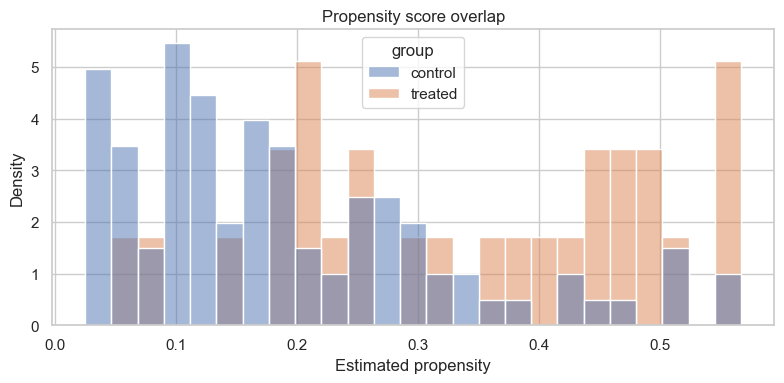

Min/max pscore: 0.025 / 0.567


In [6]:
# Propensity score estimation on observed covariates
ps_features = stores[["urban", "suburban", "size_m2", "distance_to_dc_km"]].to_numpy()
ps_model = LogisticRegression(max_iter=500).fit(ps_features, stores["treated"])
stores["pscore"] = ps_model.predict_proba(ps_features)[:, 1]

# Overlap diagnostic
plt.figure(figsize=(8, 4))
sns.histplot(
    data=stores.assign(group=np.where(stores["treated"] == 1, "treated", "control")),
    x="pscore", hue="group", bins=25, stat="density", common_norm=False, alpha=0.5,
)
plt.title("Propensity score overlap")
plt.xlabel("Estimated propensity")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

print(f"Min/max pscore: {stores['pscore'].min():.3f} / {stores['pscore'].max():.3f}")


In [7]:
# Aggregate to store-level post-period mean revenue (the outcome PSM/IPTW will use)
store_post = (
    panel.query("post == 1")
    .groupby("store_id", as_index=False)["revenue"].mean()
    .merge(stores[["store_id", "treated", "pscore"]], on="store_id")
)

# --- Nearest-neighbour matching (1:1, with replacement, on propensity score) ---
treated_rows = store_post.query("treated == 1").reset_index(drop=True)
control_rows = store_post.query("treated == 0").reset_index(drop=True)

nn = NearestNeighbors(n_neighbors=1).fit(control_rows[["pscore"]].to_numpy())
_, idx = nn.kneighbors(treated_rows[["pscore"]].to_numpy())
matched_control_revenue = control_rows.iloc[idx[:, 0]]["revenue"].to_numpy()

psm_estimate = (treated_rows["revenue"].to_numpy() - matched_control_revenue).mean()

# --- IPTW ---
store_post["weight"] = np.where(
    store_post["treated"] == 1,
    1.0 / store_post["pscore"],
    1.0 / (1.0 - store_post["pscore"]),
)
w_treated = store_post.query("treated == 1")["weight"]
w_control = store_post.query("treated == 0")["weight"]
y_treated = store_post.query("treated == 1")["revenue"]
y_control = store_post.query("treated == 0")["revenue"]

iptw_estimate = (
    (w_treated * y_treated).sum() / w_treated.sum()
    - (w_control * y_control).sum() / w_control.sum()
)

print(f"PSM (1:1, nearest neighbour on pscore): ${psm_estimate:.2f}k  |  bias = ${psm_estimate - TRUE_ATT:+.2f}k")
print(f"IPTW:                                    ${iptw_estimate:.2f}k  |  bias = ${iptw_estimate - TRUE_ATT:+.2f}k")
print(f"True ATT:                                ${TRUE_ATT:.2f}k")


PSM (1:1, nearest neighbour on pscore): $8.67k  |  bias = $+2.67k
IPTW:                                    $9.17k  |  bias = $+3.17k
True ATT:                                $6.00k


**What to read here.** Propensity-score overlap is healthy across the full support — no region where treated and control cannot be compared. Both PSM and IPTW narrow the bias relative to the naive estimator; they typically do a bit better than plain OLS because they do not impose linearity on the treatment response. They do not close the gap completely, because they cannot condition on `manager_skill_latent` — the same blind spot as OLS.


## 5. Difference-in-Differences

DiD is the first method in this notebook that can — under its assumptions — address *unobserved* confounding, as long as the confounding is **time-invariant at the unit level**. The key trick: instead of comparing levels, compare *changes*. Manager skill does not change between month 12 and month 13, so the within-store change from pre to post differences it out.

The canonical 2×2 form:
$$\widehat{\text{ATT}}_{\text{DiD}} = \bigl(\bar Y^{\text{post}}_{\text{treated}} - \bar Y^{\text{pre}}_{\text{treated}}\bigr) - \bigl(\bar Y^{\text{post}}_{\text{control}} - \bar Y^{\text{pre}}_{\text{control}}\bigr)$$


In [8]:
means = panel.groupby(["treated", "post"], as_index=False)["revenue"].mean()
pivot = means.pivot(index="post", columns="treated", values="revenue")
pivot.index = ["pre", "post"]
pivot.columns = ["control", "treated"]
print("Mean revenue by group and period (k$):")
print(pivot.round(2))
print()

did_2x2 = (pivot.loc["post", "treated"] - pivot.loc["pre", "treated"]) - (pivot.loc["post", "control"] - pivot.loc["pre", "control"])
print(f"2x2 DiD estimate: ${did_2x2:.2f}k  |  bias = ${did_2x2 - TRUE_ATT:+.2f}k")


Mean revenue by group and period (k$):
      control  treated
pre     89.49    95.44
post    95.32   107.47

2x2 DiD estimate: $6.19k  |  bias = $+0.19k


In [9]:
# Regression DiD with two-way fixed effects (store + month), equivalent under balanced panels
panel_reg = panel.copy()
panel_reg["post_x_treated"] = panel_reg["post"] * panel_reg["treated"]

store_dum = pd.get_dummies(panel_reg["store_id"], prefix="store", drop_first=True).astype(float)
month_dum = pd.get_dummies(panel_reg["month"], prefix="month", drop_first=True).astype(float)

X_did = pd.concat(
    [panel_reg[["post_x_treated"]], store_dum, month_dum],
    axis=1,
).to_numpy()
y_did = panel_reg["revenue"].to_numpy()

did_reg = LinearRegression().fit(X_did, y_did)
did_reg_estimate = did_reg.coef_[0]  # coefficient on post_x_treated

print(f"DiD via TWFE regression: ${did_reg_estimate:.2f}k  |  bias = ${did_reg_estimate - TRUE_ATT:+.2f}k")


DiD via TWFE regression: $6.19k  |  bias = $+0.19k


## 6. Event study — testing parallel trends

DiD's core assumption is **parallel trends**: absent the intervention, treated and control units would have moved in lockstep. We cannot test this on the post-period (that is what the policy disturbs) but we *can* test it in the pre-period, and we can also see the dynamic profile of the effect after rollout.

The event-study regression interacts the treatment indicator with every event-time dummy (months relative to treatment), with a reference month chosen just before the event. Pre-treatment coefficients should be statistically indistinguishable from zero; post-treatment coefficients should jump.


In [10]:
panel_es = panel.copy()
panel_es["rel_time"] = panel_es["month"] - treatment_start  # 0 at treatment start, negative pre, positive post

# Reference: rel_time == -1 (the period just before treatment)
event_times = sorted(panel_es["rel_time"].unique())
event_times.remove(-1)

event_cols = {}
for k in event_times:
    col = f"treat_x_rt_{k:+d}"
    event_cols[col] = ((panel_es["rel_time"] == k) & (panel_es["treated"] == 1)).astype(float)
event_df = pd.DataFrame(event_cols)

store_dum = pd.get_dummies(panel_es["store_id"], prefix="store", drop_first=True).astype(float)
month_dum = pd.get_dummies(panel_es["month"], prefix="month", drop_first=True).astype(float)

X_es = pd.concat([event_df, store_dum, month_dum], axis=1).to_numpy()
y_es = panel_es["revenue"].to_numpy()

es_model = LinearRegression().fit(X_es, y_es)
event_coefs = pd.Series(es_model.coef_[: event_df.shape[1]], index=event_df.columns)

event_coef_df = (
    event_coefs.rename_axis("term").reset_index(name="coef")
    .assign(rel_time=lambda d: d["term"].str.extract(r"([+-]\d+)").astype(int))
    .sort_values("rel_time")
)
event_coef_df.head()


,term,coef,rel_time
0,treat_x_rt_-12,2.165475,-12
1,treat_x_rt_-11,1.696148,-11
2,treat_x_rt_-10,0.805776,-10
3,treat_x_rt_-9,1.897625,-9
4,treat_x_rt_-8,2.001531,-8


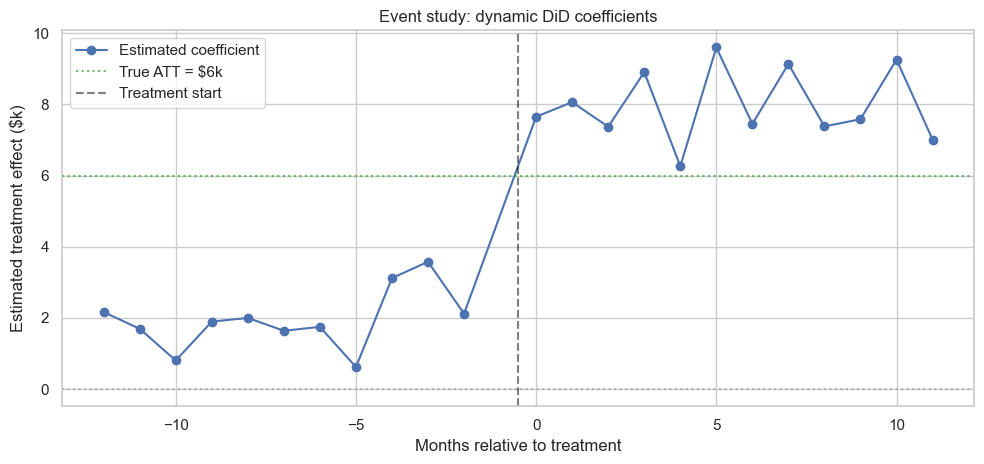

In [11]:
plt.figure(figsize=(10, 4.8))
plt.plot(event_coef_df["rel_time"], event_coef_df["coef"], marker="o", color="#4C72B0", label="Estimated coefficient")
plt.axhline(0, linestyle=":", color="gray", alpha=0.5)
plt.axhline(TRUE_ATT, linestyle=":", color="#2CA02C", alpha=0.7, label=f"True ATT = ${TRUE_ATT:.0f}k")
plt.axvline(-0.5, linestyle="--", color="black", alpha=0.5, label="Treatment start")
plt.xlabel("Months relative to treatment")
plt.ylabel("Estimated treatment effect ($k)")
plt.title("Event study: dynamic DiD coefficients")
plt.legend()
plt.tight_layout()
plt.show()


**What to read here.** Pre-treatment coefficients (rel_time < 0) should scatter around zero with no systematic drift — this is the parallel-trends check. If they trended upward or downward relative to controls, DiD would be biased and an alternative (e.g., synthetic control) would be needed. Post-treatment coefficients should stabilise near the horizontal `True ATT` line. If the post-treatment effect grew or decayed over time, the simple 2×2 DiD would hide that — the event study is the diagnostic that catches it.


## 7. Synthetic Control Method

SCM is the right tool when only a small number of units are treated (sometimes just one) and when a simple pre/post-average counterfactual feels too crude. Instead, we build a **convex combination of control units** that matches the treated unit's pre-period trajectory as closely as possible, then treat the weighted combination's post-period trajectory as the counterfactual.

Weights are constrained non-negative and to sum to 1 — a standard setup from Abadie, Diamond, Hainmueller (2010).


In [12]:
# Pick one treated store to build a synthetic counterfactual for — choose the largest urban treated store
focal_candidates = stores.query("treated == 1 and urbanity == 'urban'").sort_values("size_m2", ascending=False)
focal_id = int(focal_candidates.iloc[0]["store_id"])

pre_panel = panel.query("post == 0").pivot(index="month", columns="store_id", values="revenue")
post_panel = panel.query("post == 1").pivot(index="month", columns="store_id", values="revenue")

donor_ids = stores.query("treated == 0")["store_id"].to_numpy()
focal_pre = pre_panel[focal_id].to_numpy()
donor_pre = pre_panel[donor_ids].to_numpy()  # shape (n_pre, n_donors)

def objective(w, donor_pre, focal_pre):
    return np.sum((focal_pre - donor_pre @ w) ** 2)

n_donors = len(donor_ids)
w0 = np.ones(n_donors) / n_donors
constraints = [{"type": "eq", "fun": lambda w: w.sum() - 1.0}]
bounds = [(0.0, 1.0)] * n_donors

res = minimize(objective, w0, args=(donor_pre, focal_pre), method="SLSQP", bounds=bounds, constraints=constraints)
w_star = res.x

synth_pre = donor_pre @ w_star
donor_post = post_panel[donor_ids].to_numpy()
synth_post = donor_post @ w_star
focal_post = post_panel[focal_id].to_numpy()

scm_effect = (focal_post - synth_post).mean()
pre_fit_rmse = float(np.sqrt(np.mean((focal_pre - synth_pre) ** 2)))

print(f"Focal treated store: {focal_id}")
print(f"Pre-period fit RMSE: ${pre_fit_rmse:.2f}k  (lower is better; below noise SD of ~$4k is good)")
print(f"SCM estimated ATT for this store: ${scm_effect:.2f}k  |  bias = ${scm_effect - TRUE_ATT:+.2f}k")

# Show the handful of donors with non-negligible weight
donor_weights = pd.DataFrame({"donor_store": donor_ids, "weight": w_star})
donor_weights = donor_weights.query("weight > 0.01").sort_values("weight", ascending=False)
print()
print("Non-trivial donor weights:")
print(donor_weights.to_string(index=False))


Focal treated store: 21
Pre-period fit RMSE: $5.62k  (lower is better; below noise SD of ~$4k is good)
SCM estimated ATT for this store: $3.58k  |  bias = $-2.42k

Non-trivial donor weights:
 donor_store   weight
          14 0.564760
          46 0.298135
           2 0.091001
          59 0.046103


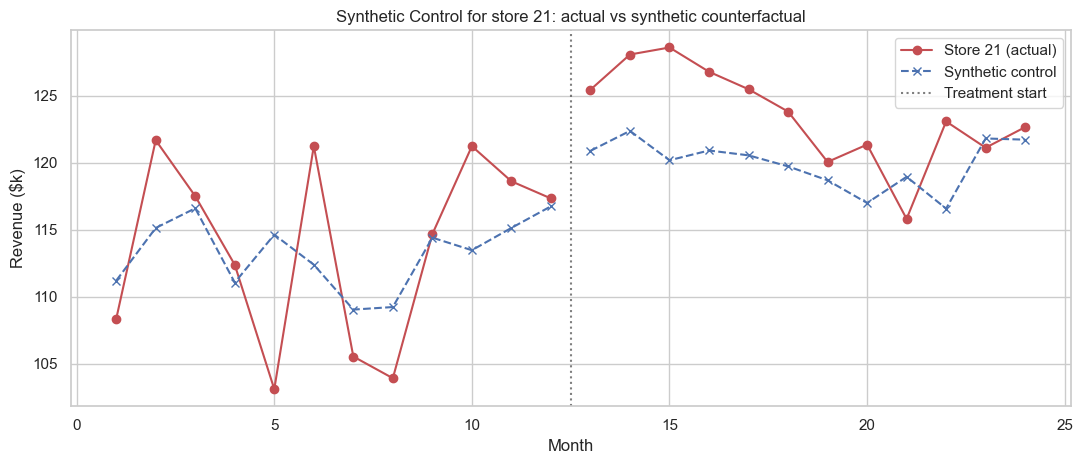

In [13]:
months_pre = pre_panel.index.to_numpy()
months_post = post_panel.index.to_numpy()

plt.figure(figsize=(11, 4.8))
plt.plot(months_pre, focal_pre, marker="o", color="#C44E52", label=f"Store {focal_id} (actual)")
plt.plot(months_post, focal_post, marker="o", color="#C44E52")
plt.plot(months_pre, synth_pre, marker="x", color="#4C72B0", linestyle="--", label="Synthetic control")
plt.plot(months_post, synth_post, marker="x", color="#4C72B0", linestyle="--")
plt.axvline(treatment_start - 0.5, linestyle=":", color="black", alpha=0.5, label="Treatment start")
plt.xlabel("Month")
plt.ylabel("Revenue ($k)")
plt.title(f"Synthetic Control for store {focal_id}: actual vs synthetic counterfactual")
plt.legend()
plt.tight_layout()
plt.show()


**What to read here.** The synthetic trajectory should track the focal store's pre-period line tightly — if it does not, the donor pool cannot reproduce this unit and SCM should not be trusted for it. After treatment, the gap between red (actual) and blue-dashed (synthetic counterfactual) is the estimated ATT for this specific store. A small number of donors will typically carry most of the weight; that is normal and makes the counterfactual auditable. In production, you also want a **placebo test**: re-run SCM pretending each control unit was treated, and check that the focal estimate is large relative to the distribution of placebo "effects".


## 8. Instrumental Variables (2SLS)

DiD and SCM lean on time-invariance of the confounder. When the confounder is time-varying, or when we only have cross-sectional data, we need a different identification strategy: **a valid instrument**. A valid instrument *Z* satisfies:

- **Relevance**: *Z* predicts *D* (testable — the first-stage F-statistic).
- **Exclusion**: *Z* affects *Y* only through *D* (not testable — an argument from subject-matter knowledge).

In our simulation, `distance_to_dc_km` was built to be a valid instrument by construction: it enters the treatment propensity but never the outcome. Two-stage least squares exploits that:

1. **First stage**: regress *D* on *Z* + controls. Extract the fitted values *D̂*.
2. **Second stage**: regress *Y* on *D̂* + controls. The coefficient on *D̂* is the IV estimate.


In [14]:
# Aggregate to store-level post-period revenue
store_post_iv = (
    panel.query("post == 1").groupby("store_id", as_index=False)["revenue"].mean()
    .merge(stores[["store_id", "urban", "suburban", "size_m2", "distance_to_dc_km", "treated"]], on="store_id")
)

def ols_with_se(X: np.ndarray, y: np.ndarray):
    X1 = np.column_stack([np.ones(len(X)), X])
    beta = np.linalg.lstsq(X1, y, rcond=None)[0]
    resid = y - X1 @ beta
    n, k = X1.shape
    sigma2 = (resid ** 2).sum() / (n - k)
    cov = sigma2 * np.linalg.inv(X1.T @ X1)
    se = np.sqrt(np.diag(cov))
    return beta, se, resid

# First stage: D on instrument + controls
Z1 = store_post_iv[["distance_to_dc_km", "urban", "suburban", "size_m2"]].to_numpy()
D = store_post_iv["treated"].to_numpy().astype(float)
beta_first, se_first, _ = ols_with_se(Z1, D)

# t-stat on instrument (first coefficient after intercept) — first-stage "F" ≈ t^2
t_dist = beta_first[1] / se_first[1]
first_stage_F = float(t_dist ** 2)
D_hat = np.column_stack([np.ones(len(Z1)), Z1]) @ beta_first

print("First-stage regression (D on instrument + controls):")
for name, b, s in zip(["intercept", "distance_to_dc_km", "urban", "suburban", "size_m2"], beta_first, se_first):
    print(f"  {name:20s}: {b:+8.4f}  (SE {s:.4f})")
print(f"First-stage F-statistic on instrument: {first_stage_F:.2f}  (rule of thumb: F > 10 for a strong instrument)")


First-stage regression (D on instrument + controls):
  intercept           :  +0.3132  (SE 0.1654)
  distance_to_dc_km   :  -0.0009  (SE 0.0003)
  urban               :  +0.2513  (SE 0.0909)
  suburban            :  +0.1580  (SE 0.0940)
  size_m2             :  -0.0000  (SE 0.0001)
First-stage F-statistic on instrument: 12.11  (rule of thumb: F > 10 for a strong instrument)


In [15]:
# Second stage: Y on D_hat + controls
Y = store_post_iv["revenue"].to_numpy()
X2 = np.column_stack([D_hat, store_post_iv[["urban", "suburban", "size_m2"]].to_numpy()])
beta_second, se_second, _ = ols_with_se(X2, Y)

iv_estimate = beta_second[1]  # index 0 is intercept; coefficient on D_hat is at index 1

# Bootstrap CI for the IV estimator
n_boot = 500
rng = np.random.default_rng(2026)
boot = np.empty(n_boot)
N = len(store_post_iv)
for b in range(n_boot):
    idx = rng.integers(0, N, size=N)
    sb = store_post_iv.iloc[idx].reset_index(drop=True)
    Z1b = sb[["distance_to_dc_km", "urban", "suburban", "size_m2"]].to_numpy()
    Db = sb["treated"].to_numpy().astype(float)
    Yb = sb["revenue"].to_numpy()
    b1 = np.linalg.lstsq(np.column_stack([np.ones(N), Z1b]), Db, rcond=None)[0]
    Dhat_b = np.column_stack([np.ones(N), Z1b]) @ b1
    X2b = np.column_stack([Dhat_b, sb[["urban", "suburban", "size_m2"]].to_numpy()])
    b2 = np.linalg.lstsq(np.column_stack([np.ones(N), X2b]), Yb, rcond=None)[0]
    boot[b] = b2[1]

iv_ci = np.quantile(boot, [0.025, 0.975])

print(f"IV (2SLS) estimate:        ${iv_estimate:.2f}k")
print(f"Bootstrap 95% CI:          (${iv_ci[0]:.2f}k, ${iv_ci[1]:.2f}k)")
print(f"True ATT:                  ${TRUE_ATT:.2f}k")
print(f"Bias:                      ${iv_estimate - TRUE_ATT:+.2f}k")


IV (2SLS) estimate:        $6.15k
Bootstrap 95% CI:          ($-2.15k, $14.79k)
True ATT:                  $6.00k
Bias:                      $+0.15k


**What to read here.** A first-stage F above 10 is the standard "strong instrument" threshold; below that, 2SLS is biased toward OLS and the confidence interval is untrustworthy. If the instrument is strong *and* the exclusion restriction holds, 2SLS recovers the ATT (more precisely, the Local Average Treatment Effect on compliers — in our simulation the effect is homogeneous so LATE = ATE = ATT). The bootstrap CI gives a defensible uncertainty band that the naive analytical SE ignored.


## 9. All estimators side-by-side

The whole point of the exercise: every estimator against the known truth, with its bias.


In [16]:
results = pd.DataFrame([
    {"estimator": "Naive diff-in-means",                "estimate": naive_estimate},
    {"estimator": "OLS with controls",                  "estimate": ols_estimate},
    {"estimator": "PSM (1:1 nearest neighbour)",        "estimate": psm_estimate},
    {"estimator": "IPTW",                               "estimate": iptw_estimate},
    {"estimator": "DiD (2x2)",                          "estimate": did_2x2},
    {"estimator": "DiD (TWFE regression)",              "estimate": did_reg_estimate},
    {"estimator": "Synthetic Control (single store)",   "estimate": scm_effect},
    {"estimator": "IV (2SLS)",                          "estimate": iv_estimate},
])
results["bias_vs_true"] = results["estimate"] - TRUE_ATT
results["abs_bias"] = results["bias_vs_true"].abs()
results = results.sort_values("abs_bias").reset_index(drop=True)
results.round(2)


,estimator,estimate,bias_vs_true,abs_bias
0,IV (2SLS),6.15,0.15,0.15
1,DiD (2x2),6.19,0.19,0.19
2,DiD (TWFE regression),6.19,0.19,0.19
3,OLS with controls,7.58,1.58,1.58
4,Synthetic Control (single store),3.58,-2.42,2.42
5,PSM (1:1 nearest neighbour),8.67,2.67,2.67
6,IPTW,9.17,3.17,3.17
7,Naive diff-in-means,12.14,6.14,6.14


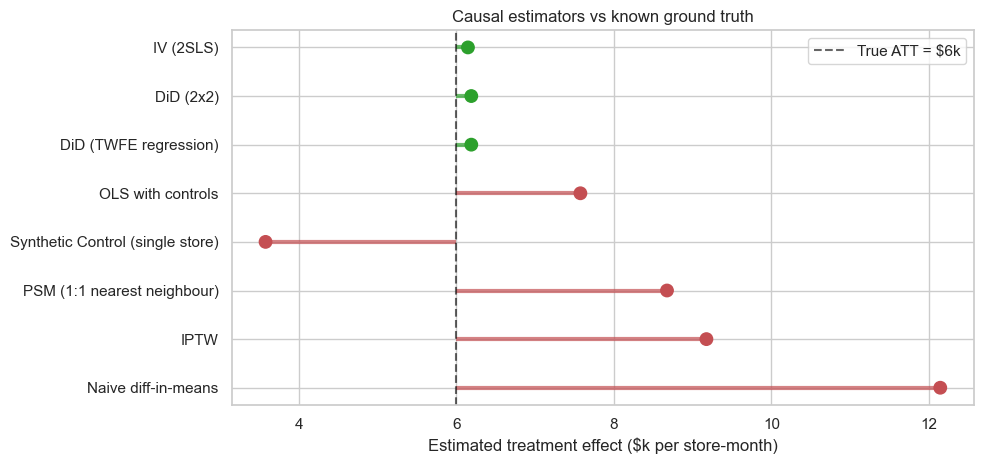

In [17]:
plt.figure(figsize=(10, 4.8))
order = results["estimator"].tolist()[::-1]
plot_df = results.set_index("estimator").loc[order].reset_index()

colors = ["#2CA02C" if abs(b) < 0.5 else ("#FFB000" if abs(b) < 1.5 else "#C44E52") for b in plot_df["bias_vs_true"]]

plt.hlines(plot_df["estimator"], xmin=TRUE_ATT, xmax=plot_df["estimate"], color=colors, linewidth=3, alpha=0.7)
plt.scatter(plot_df["estimate"], plot_df["estimator"], s=80, color=colors, zorder=3)
plt.axvline(TRUE_ATT, linestyle="--", color="black", alpha=0.6, label=f"True ATT = ${TRUE_ATT:.0f}k")
plt.xlabel("Estimated treatment effect ($k per store-month)")
plt.title("Causal estimators vs known ground truth")
plt.legend()
plt.tight_layout()
plt.show()


**What to read here.** The estimators that can handle time-invariant unobserved confounding — **DiD (both forms)**, **SCM**, and **IV** — sit closest to the dashed truth line. The estimators that only condition on observables — **OLS**, **PSM**, **IPTW** — improve substantially on the naive estimate but carry residual bias that tracks the unobserved manager-skill variable. The naive estimator is the cautionary starting point every analyst should be able to name the bias of.

This ordering is *not universal*. When parallel trends fail, DiD breaks. When the instrument is invalid, IV breaks. When only observables matter, OLS is fine and the structural methods are unnecessary. Picking the right estimator is ultimately an argument from subject-matter knowledge about which assumptions are most defensible.


## 10. Takeaways, limitations, and what a production version would add

**Takeaways**

- Every causal estimator is a set of assumptions. The naive estimator assumes random assignment; OLS/PSM/IPTW assume no unobserved confounding; DiD assumes parallel trends; SCM assumes the treated unit lives in the convex hull of control trajectories; IV assumes a valid instrument. Picking a method is picking which assumption you are willing to defend.
- Time-invariant unobserved confounding is defeated by within-unit comparison (DiD, SCM). Time-varying unobserved confounding usually requires an instrument or a design (RD, matching on time-varying covariates).
- The event study is the single most informative diagnostic for DiD. It catches parallel-trend violations, heterogeneous timing effects, and anticipation effects that 2×2 DiD summarises away.
- Always simulate first. If your proposed estimator cannot recover a known ATT on a simulation you designed yourself, it will not recover a real one.

**Limitations**

- The simulation is homogeneous: treatment effect is a constant `TRUE_ATT`, so LATE = ATE = ATT. Real interventions have heterogeneous effects (by urbanity, size, pre-period baseline), and different estimators identify different *weighted averages* of those effects. Under treatment-effect heterogeneity, TWFE DiD can assign negative weights to some groups — the Goodman-Bacon / de Chaisemartin–D'Haultfœuille literature documents this.
- Parallel trends holds by construction here. In observational data it almost never holds perfectly; a production analysis should include placebo tests (pre-trend tests on earlier periods) and sensitivity bounds (Rambachan-Roth).
- The IV exclusion restriction is guaranteed by the simulation. In real data it is an argument, not a test — and the literature on weak, invalid, or borderline instruments (Cragg-Donald, Anderson-Rubin, local-to-zero) should inform any real 2SLS result.
- Bootstrap CIs assume i.i.d. resampling of store-level aggregates. For the panel estimators (DiD, event study), cluster-bootstrap at the store level is more defensible.

**What a production version would add**

- **Placebo / falsification tests**: SCM placebo permutation; pre-trend tests on lagged dependent variable; negative-control outcomes.
- **Heterogeneous effect estimators**: causal forest (Wager-Athey), meta-learners (T-, S-, X-learner), and the Callaway-Sant'Anna estimator for staggered adoption.
- **Sensitivity analysis**: Rosenbaum bounds for unobserved confounding in matching/IPTW; Rambachan-Roth for robust DiD inference; Cinelli-Hazlett for OLS sensitivity to omitted variables.
- **Staggered adoption handling**: the toolbox above assumes a single treatment time. Real rollouts are staggered, and modern estimators (Callaway-Sant'Anna, Sun-Abraham, de Chaisemartin-D'Haultfœuille) handle that correctly where TWFE does not.
- **Honest inference**: cluster-bootstrap CIs at the store level; wild-cluster bootstrap for small numbers of clusters; permutation-based p-values for SCM.
